In [1]:
# Install required libraries
!pip install pandas numpy scikit-learn matplotlib seaborn tensorflow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [3]:
import zipfile

zip_path = "/content/dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted successfully")

Dataset extracted successfully


In [4]:
import os

os.listdir("/content/dataset")

['RT_IOT2022.csv', 'rt-iot2022']

In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/dataset/RT_IOT2022.csv")

# Show first rows
df.head()

,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [6]:
df = df.drop(columns=["Unnamed: 0"])

df.head()

,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [7]:
df.isnull().sum()

,0
id.orig_p,0
id.resp_p,0
proto,0
service,0
flow_duration,0
...,...
idle.std,0
fwd_init_window_size,0
bwd_init_window_size,0
fwd_last_window_size,0


In [8]:
# Features (input variables)
X = df.drop("Attack_type", axis=1)

# Target (label)
y = df["Attack_type"]

print(X.shape)
print(y.shape)

(123117, 83)
(123117,)


In [9]:
from sklearn.preprocessing import LabelEncoder

# find categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['proto', 'service', 'Attack_type'], dtype='object')


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['proto'] = le.fit_transform(df['proto'])
df['service'] = le.fit_transform(df['service'])
df['Attack_type'] = le.fit_transform(df['Attack_type'])

In [11]:
# recreate features and target after encoding
X = df.drop("Attack_type", axis=1)
y = df["Attack_type"]


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(98493, 83)
(24624, 83)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Train model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log, average='weighted')
recall = recall_score(y_test, y_pred_log, average='weighted')
f1 = f1_score(y_test, y_pred_log, average='weighted')

print("Logistic Regression Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Results
Accuracy: 0.9892787524366472
Precision: 0.9892692592648066
Recall: 0.9892787524366472
F1 Score: 0.989145877744076

Confusion Matrix:
[[ 1454     2     0     2     0     0     3     0     2     0   111     4]
 [    3    71     0     0     0     0     0     0    26     0     0     0]
 [    0     0 18897     0     0     0     0     0     0     0     0     0]
 [    1     0     0   870     0     0     0     0     0     0     0     0]
 [    2     0     0     0     4     0     0     0     0     0     0     0]
 [    1     0     0     0     0     2     0     0     0     0     0     0]
 [    0     0     0     0     0     0   393     0     0     0     0     0]
 [    0     0     0     0     0     0     0   220     0     0     0     0]
 [   12     1     0     0     0     0     0     0   474     0     2     0]
 [    3     0     0     0     0     0     0     0     0   381     0     0]
 [   65     0     0     0     1     1     0     0     1     0  1555     2]
 [    3     1 

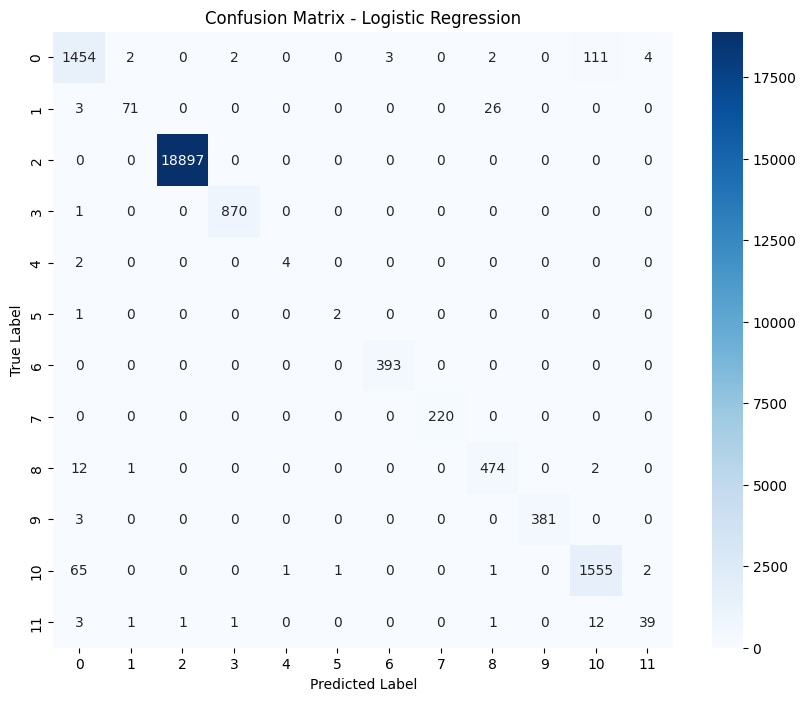

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Train model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn, average='weighted')
recall = recall_score(y_test, y_pred_knn, average='weighted')
f1 = f1_score(y_test, y_pred_knn, average='weighted')

print("KNN Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

KNN Results
Accuracy: 0.99545159194282
Precision: 0.9954724453059888
Recall: 0.99545159194282
F1 Score: 0.9954236432143496


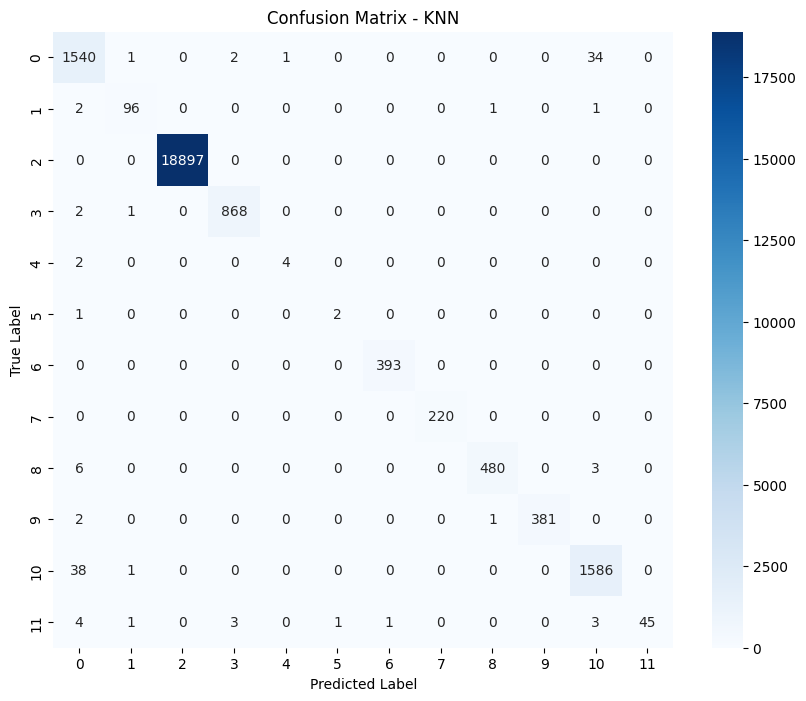

In [17]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(10,8))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='weighted')
recall = recall_score(y_test, y_pred_rf, average='weighted')
f1 = f1_score(y_test, y_pred_rf, average='weighted')

print("Random Forest Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Random Forest Results
Accuracy: 0.9980100714749838
Precision: 0.9980338744685031
Recall: 0.9980100714749838
F1 Score: 0.9980094574996761


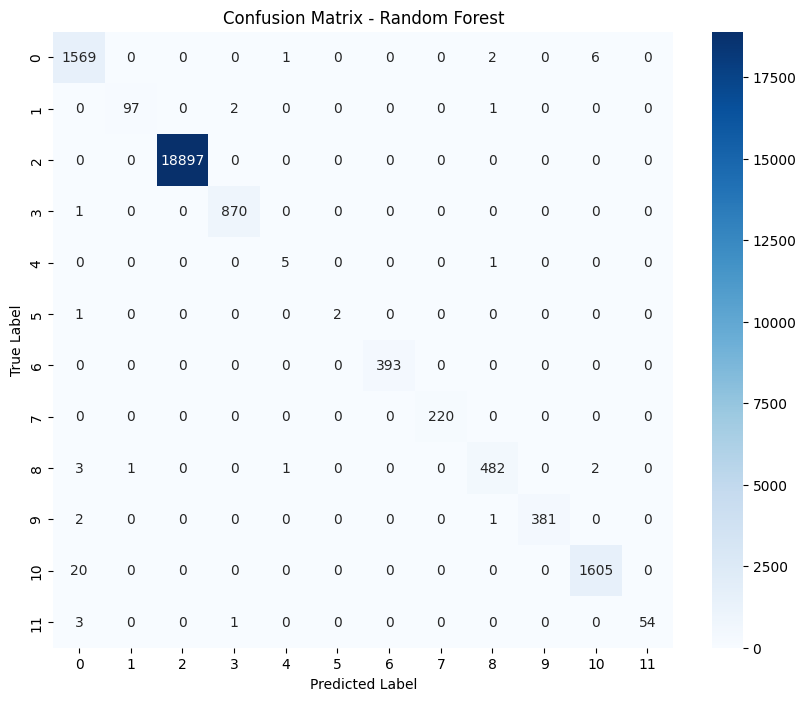

In [19]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10,8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [20]:
from sklearn.svm import SVC

# Train model
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred_svm)
precision = precision_score(y_test, y_pred_svm, average='weighted')
recall = recall_score(y_test, y_pred_svm, average='weighted')
f1 = f1_score(y_test, y_pred_svm, average='weighted')

print("SVM Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

SVM Results
Accuracy: 0.9929337231968811
Precision: 0.9931782950934983
Recall: 0.9929337231968811
F1 Score: 0.992780393635857


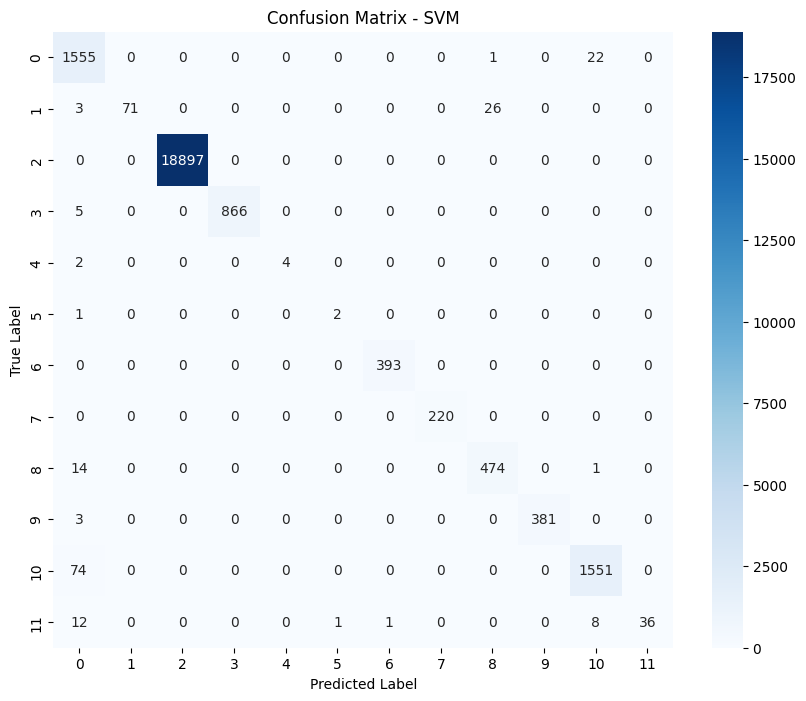

In [21]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10,8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Build ANN model
ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(len(set(y)), activation='softmax')
])

# Compile model
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
ann_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Predictions
y_pred_ann_prob = ann_model.predict(X_test)
y_pred_ann = y_pred_ann_prob.argmax(axis=1)

# Evaluation
accuracy = accuracy_score(y_test, y_pred_ann)
precision = precision_score(y_test, y_pred_ann, average='weighted')
recall = recall_score(y_test, y_pred_ann, average='weighted')
f1 = f1_score(y_test, y_pred_ann, average='weighted')

print("ANN Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9579 - loss: 0.1780 - val_accuracy: 0.9905 - val_loss: 0.0340
Epoch 2/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9912 - loss: 0.0310 - val_accuracy: 0.9917 - val_loss: 0.0322
Epoch 3/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9934 - loss: 0.0232 - val_accuracy: 0.9943 - val_loss: 0.0236
Epoch 4/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9942 - loss: 0.0227 - val_accuracy: 0.9935 - val_loss: 0.0245
Epoch 5/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9951 - loss: 0.0173 - val_accuracy: 0.9942 - val_loss: 0.0183
Epoch 6/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9953 - loss: 0.0141 - val_accuracy: 0.9958 - val_loss: 0.0161
Epoch 7/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9960 - loss: 0.0124 - val_accuracy: 0.9961 - val_loss: 0.0174
Epoch 8/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9959 - loss: 0.0117 - 

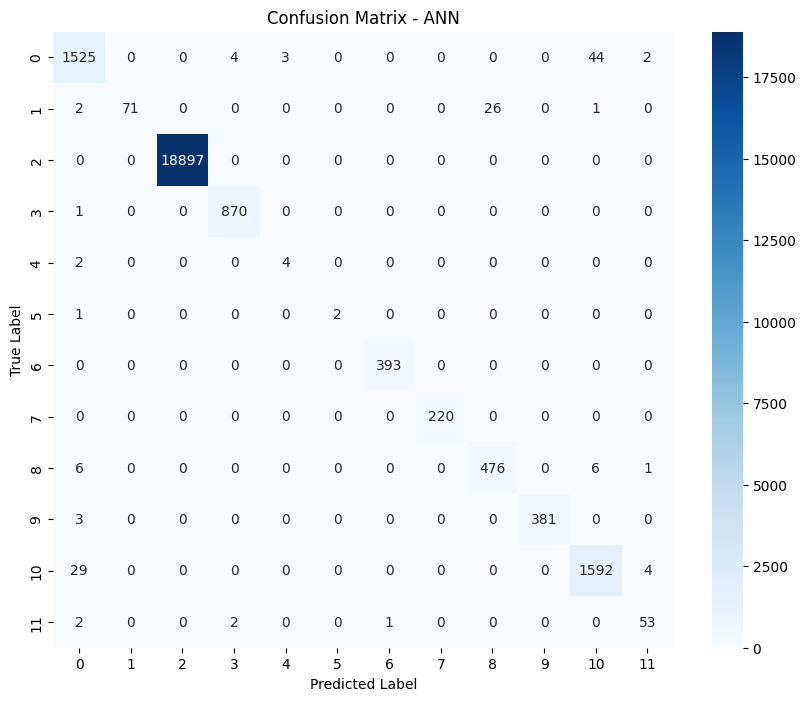

In [23]:
cm_ann = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(10,8))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - ANN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import numpy as np

# reshape data for LSTM
X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_lstm = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# build LSTM model
lstm_model = Sequential()

lstm_model.add(LSTM(64, input_shape=(X_train_lstm.shape[1], 1)))
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dense(len(set(y)), activation='softmax'))

# compile
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# train
lstm_model.fit(X_train_lstm, y_train, epochs=10, batch_size=32, validation_split=0.2)

# predictions
y_pred_lstm_prob = lstm_model.predict(X_test_lstm)
y_pred_lstm = y_pred_lstm_prob.argmax(axis=1)

# evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_lstm)
precision = precision_score(y_test, y_pred_lstm, average='weighted')
recall = recall_score(y_test, y_pred_lstm, average='weighted')
f1 = f1_score(y_test, y_pred_lstm, average='weighted')

print("LSTM Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2463/2463 ━━━━━━━━━━━━━━━━━━━━ 100s 40ms/step - accuracy: 0.8490 - loss: 0.5863 - val_accuracy: 0.9647 - val_loss: 0.1193
Epoch 2/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 141s 39ms/step - accuracy: 0.9636 - loss: 0.1146 - val_accuracy: 0.9797 - val_loss: 0.0697
Epoch 3/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 95s 39ms/step - accuracy: 0.9738 - loss: 0.0776 - val_accuracy: 0.9836 - val_loss: 0.0508
Epoch 4/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 94s 38ms/step - accuracy: 0.9804 - loss: 0.0626 - val_accuracy: 0.9852 - val_loss: 0.0508
Epoch 5/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 96s 39ms/step - accuracy: 0.9824 - loss: 0.0546 - val_accuracy: 0.9820 - val_loss: 0.0539
Epoch 6/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 96s 39ms/step - accuracy: 0.9820 - loss: 0.0578 - val_accuracy: 0.9861 - val_loss: 0.0443
Epoch 7/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 94s 38ms/step - accuracy: 0.9810 - loss: 0.0586 - val_accuracy: 0.9868 - val_loss: 0.0421
Epoch 8/10
2463/2463 ━━━━━━━━━━━━━━━━━━━━ 93s 38ms/step - accuracy: 0.9853 - loss: 0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


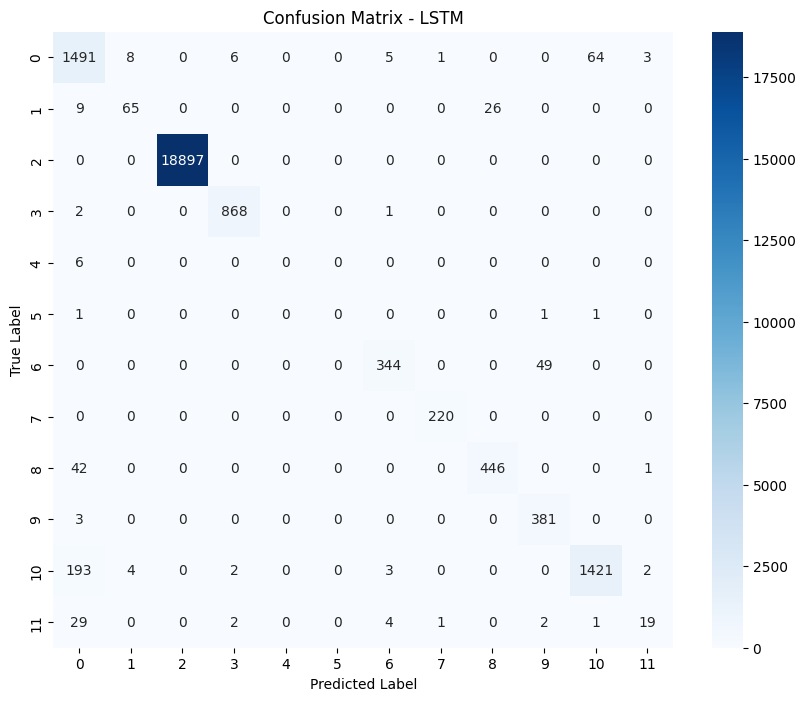

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

# Get class labels
class_labels = sorted(y.unique())

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(cm_lstm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.title("Confusion Matrix - LSTM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

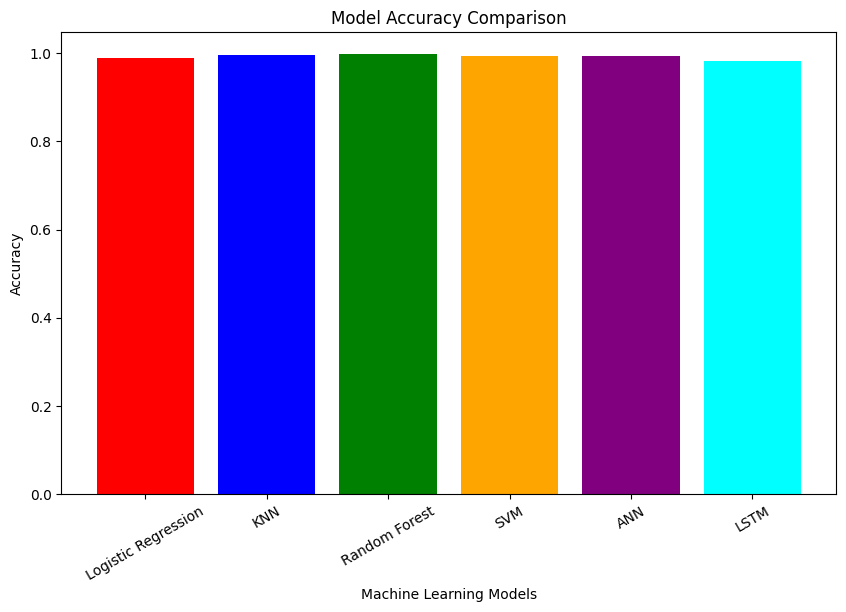

In [27]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "KNN",
    "Random Forest",
    "SVM",
    "ANN",
    "LSTM"
]

accuracy_scores = [
    0.9893,
    0.9955,
    0.9980,
    0.9929,
    0.9940,
    0.9825
]

colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan']

plt.figure(figsize=(10,6))
plt.bar(models, accuracy_scores, color=colors)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)

plt.show()

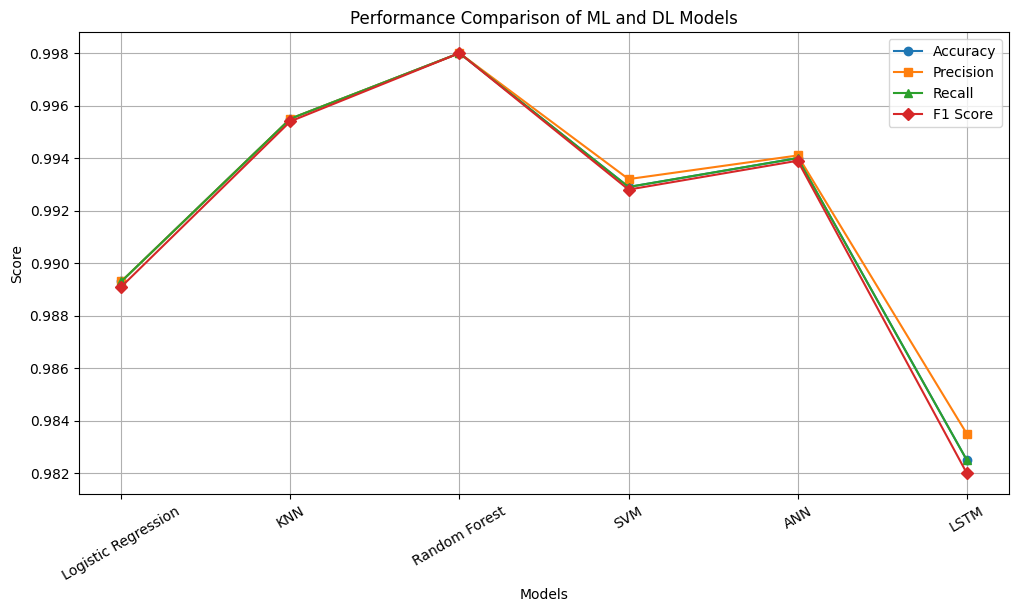

In [28]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "KNN",
    "Random Forest",
    "SVM",
    "ANN",
    "LSTM"
]

accuracy = [0.9893, 0.9955, 0.9980, 0.9929, 0.9940, 0.9825]
precision = [0.9893, 0.9955, 0.9980, 0.9932, 0.9941, 0.9835]
recall = [0.9893, 0.9955, 0.9980, 0.9929, 0.9940, 0.9825]
f1 = [0.9891, 0.9954, 0.9980, 0.9928, 0.9939, 0.9820]

plt.figure(figsize=(12,6))

plt.plot(models, accuracy, marker='o', label='Accuracy')
plt.plot(models, precision, marker='s', label='Precision')
plt.plot(models, recall, marker='^', label='Recall')
plt.plot(models, f1, marker='D', label='F1 Score')

plt.title("Performance Comparison of ML and DL Models")
plt.xlabel("Models")
plt.ylabel("Score")

plt.xticks(rotation=30)

plt.legend()
plt.grid(True)

plt.show()

/tmp/ipykernel_390/3156337813.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attack_type', data=df, palette='Set2')


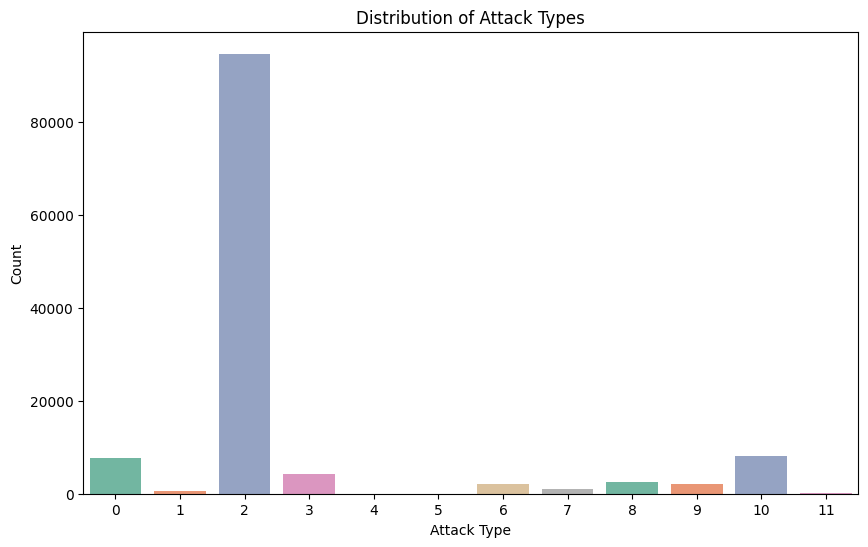

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.countplot(x='Attack_type', data=df, palette='Set2')

plt.title("Distribution of Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Count")

plt.show()

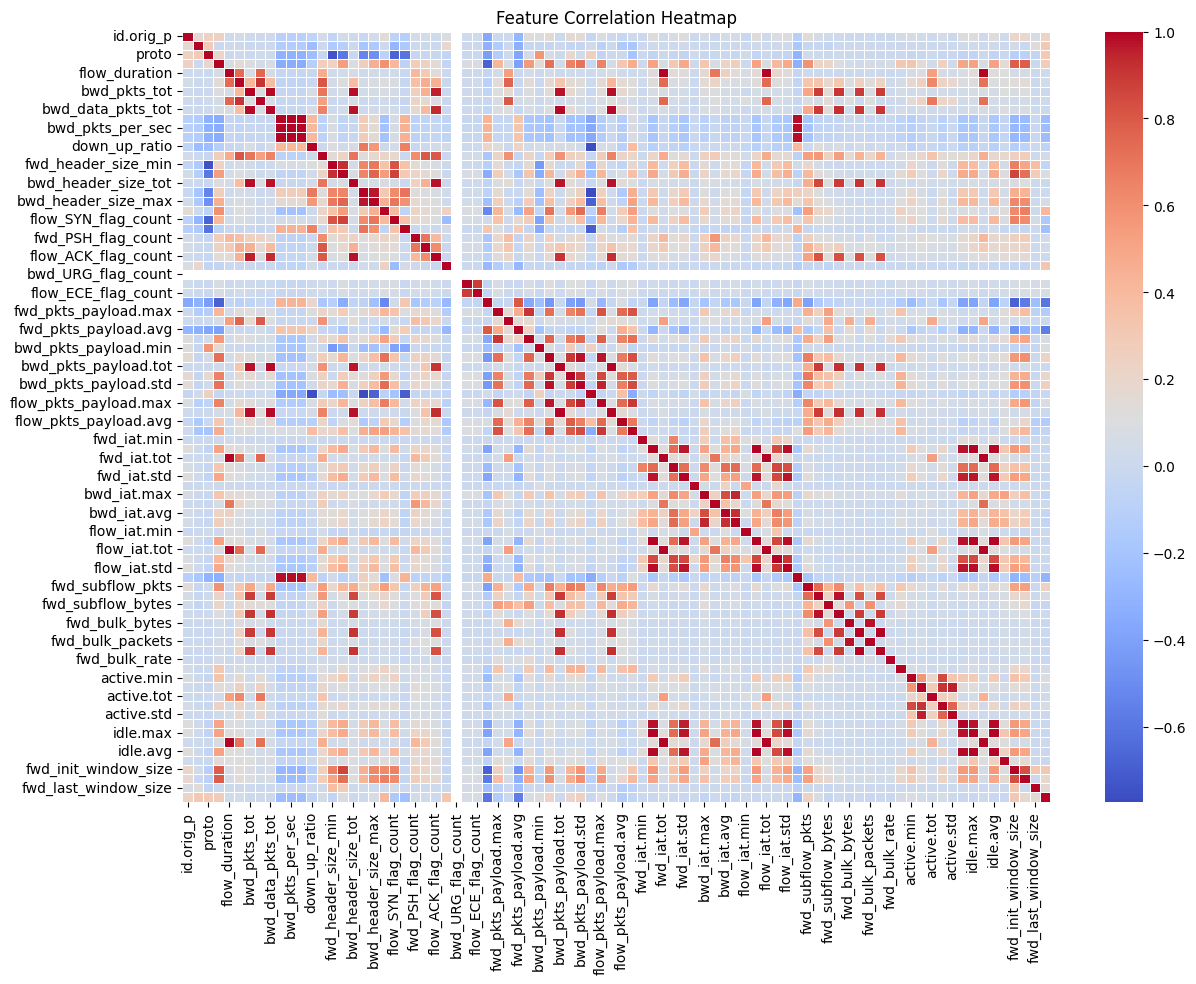

In [30]:
plt.figure(figsize=(14,10))

correlation_matrix = df.corr()

sns.heatmap(correlation_matrix,
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Feature Correlation Heatmap")

plt.show()

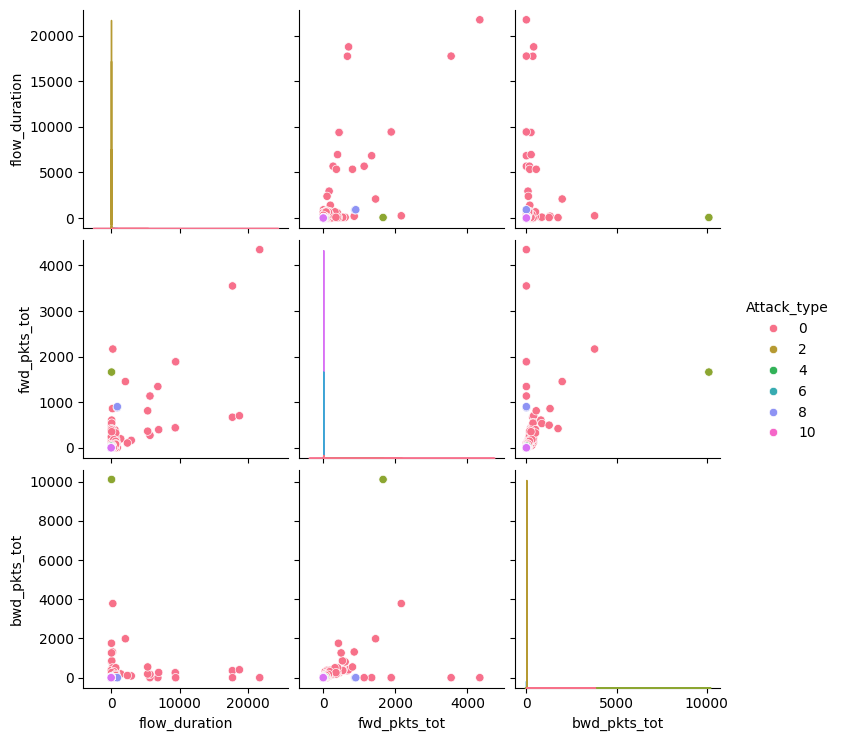

In [31]:
sns.pairplot(df[['flow_duration','fwd_pkts_tot','bwd_pkts_tot','Attack_type']],
             hue='Attack_type',
             palette='husl')

plt.show()